NOMBRE: LLANOS ROJAS JHONN WILDER      CICO


In [94]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

In [95]:
class Buscaminas:
    def __init__(self):
        self.filas = 3
        self.columnas = 3
        self.num_minas = 2
        self.reset()

    def reset(self):
        # tablero real con minas(-1) y numeros
        self.tablero = np.zeros((self.filas, self.columnas), dtype=int)
        # lo que ve el agente: -2=cerrada, -1=mina, 0+=abierta
        self.visible = np.full((self.filas, self.columnas), -2, dtype=int)
        self.terminado = False
        self.gano = False
        minas = random.sample(range(self.filas * self.columnas), self.num_minas)
        for pos in minas:
            self.tablero[pos // self.columnas][pos % self.columnas] = -1
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.tablero[i][j] != -1:
                    self.tablero[i][j] = sum(
                        1 for vi, vj in self._vecinos(i, j)
                        if self.tablero[vi][vj] == -1
                    )

    def _vecinos(self, i, j):
        return [
            (i+di, j+dj)
            for di in [-1, 0, 1] for dj in [-1, 0, 1]
            if (di, dj) != (0, 0)
            and 0 <= i+di < self.filas
            and 0 <= j+dj < self.columnas
        ]

    def abrir(self, i, j):
        if self.terminado:
            return self.visible.copy(), 0, True
        if self.tablero[i][j] == -1:
            self.visible[i][j] = -1
            self.terminado = True
            return self.visible.copy(), -5, True
        self.visible[i][j] = self.tablero[i][j]
        recompensa = 1
        seguras = self.filas * self.columnas - self.num_minas
        if np.sum(self.visible >= 0) == seguras:
            self.terminado = True
            self.gano = True
            recompensa = 3
        return self.visible.copy(), recompensa, self.terminado

    def cerradas(self):
        return [
            (i, j)
            for i in range(self.filas)
            for j in range(self.columnas)
            if self.visible[i][j] == -2
        ]

In [96]:
class AgenteUCB:
    def __init__(self):
        self.alpha = 0.5   # tasa de aprendizaje
        self.c = 1.5   # constante de exploracion
        self.Q = {}        # valor estimado por casilla
        self.N = {}        # veces que se eligio cada casilla
        self.t = 1         # paso global
        self.recompensa_ep = 0

    def reset(self):
        self.recompensa_ep = 0

    def _ucb(self, casilla):
        q = self.Q.get(casilla, 0.0)
        n = self.N.get(casilla, 0)
        if n == 0:
            return float('inf')  # nunca explorada, maxima prioridad
        return q + self.c * math.sqrt(math.log(self.t) / n)

    def elegir(self, env):
        candidatas = env.cerradas()
        if not candidatas:
            return None
        # UCB: elige la casilla con mayor valor UCB
        return max(candidatas, key=self._ucb)

    def actualizar(self, casilla, recompensa):
        self.N[casilla] = self.N.get(casilla, 0) + 1
        q = self.Q.get(casilla, 0.0)
        self.Q[casilla] = q + self.alpha * (recompensa - q)
        self.t += 1
        self.recompensa_ep += recompensa

In [99]:
episodios = 500000
env = Buscaminas()
agente = AgenteUCB()

recompensas = []
victorias = []

for ep in range(episodios):
    env.reset()
    agente.reset()
    terminado = False
    while not terminado:
        accion = agente.elegir(env)
        if accion is None:
            break
        _, r, terminado = env.abrir(accion[0], accion[1])
        agente.actualizar(accion, r)
    recompensas.append(agente.recompensa_ep)
    victorias.append(1 if env.gano else 0)

print(f"Victorias: {sum(victorias)}/{episodios} ({sum(victorias)/episodios*100:.1f}%)")

Victorias: 13754/500000 (2.8%)


PERDIO


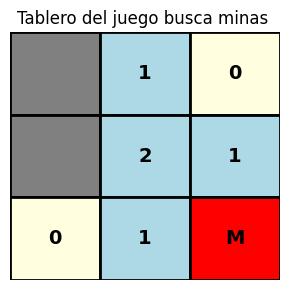

In [100]:
def ver_tablero(visible):
    filas, columnas = visible.shape
    fig, ax = plt.subplots(figsize=(columnas, filas))
    for i in range(filas):
        for j in range(columnas):
            v = visible[i][j]
            color = 'gray' if v == -2 else 'red' if v == -1 else 'lightyellow' if v == 0 else 'lightblue'
            texto = '' if v == -2 else 'M' if v == -1 else str(v)
            ax.add_patch(plt.Rectangle([j, filas-1-i], 1, 1, color=color, ec='black', lw=2))
            ax.text(j+0.5, filas-1-i+0.5, texto, ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_xlim(0, columnas)
    ax.set_ylim(0, filas)
    ax.axis('off')
    plt.title('Tablero del juego busca minas ')
    plt.tight_layout()
    plt.show()

env.reset()
terminado = False
while not terminado:
    accion = agente.elegir(env)
    if accion is None:
        break
    _, r, terminado = env.abrir(accion[0], accion[1])
    agente.actualizar(accion, r)

print("GANO" if env.gano else "PERDIO")
ver_tablero(env.visible)